# Importing all the necessary packages

In [1]:
# Regular Plotting Libraries

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn
import seaborn as sns

# Models
import sklearn
from scipy.spatial.transform import rotation
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score


#### Versions of packages

In [2]:
print(f"Numpy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

Numpy Version: 2.5.3
Pandas Version: 3.0.5
Matplotlib Version: 3.11.1
Scikit-Learn version: 1.9.0


# Loading Data

In [3]:
df = pd.read_csv("dataset/heart disease classification dataset.csv")

In [4]:
df.shape

(303, 15)

In [5]:
df.head(10)

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,male,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,yes
1,1,37,male,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,yes
2,2,41,female,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,yes
3,3,56,male,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,yes
4,4,57,female,0,NaN,354.0,0,1,163.0,1,0.6,2,0,2,yes
5,5,57,male,0,140.0,192.0,0,1,148.0,0,0.4,1,0,1,yes
6,6,56,female,1,140.0,294.0,0,0,153.0,0,1.3,1,0,2,yes
7,7,44,male,1,120.0,263.0,0,1,173.0,0,0.0,2,0,3,yes
8,8,52,male,2,172.0,199.0,1,1,162.0,0,0.5,2,0,3,yes
9,9,57,male,2,150.0,168.0,0,1,174.0,0,1.6,2,0,2,yes


# Exploring the Data

In [6]:
df.target.value_counts()

target
yes    165
no     138
Name: count, dtype: int64

<Axes: title={'center': 'Heart Disease Summary'}, xlabel='target'>

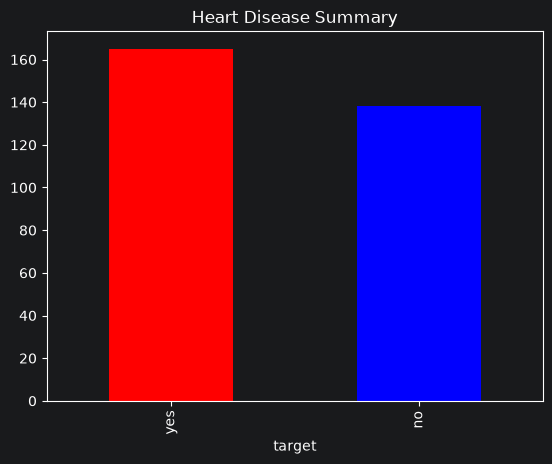

In [7]:
df.target.value_counts().plot(kind="bar", color=['red', 'blue'], title="Heart Disease Summary")

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-null    str    
 3   cp          303 non-null    int64  
 4   trestbps    299 non-null    float64
 5   chol        302 non-null    float64
 6   fbs         303 non-null    int64  
 7   restecg     303 non-null    int64  
 8   thalach     298 non-null    float64
 9   exang       303 non-null    int64  
 10  oldpeak     303 non-null    float64
 11  slope       303 non-null    int64  
 12  ca          303 non-null    int64  
 13  thal        303 non-null    int64  
 14  target      303 non-null    str    
dtypes: float64(4), int64(9), str(2)
memory usage: 35.6 KB


### Cleaning up data

In [9]:
df.isnull().sum()

Unnamed: 0    0
age           0
sex           0
cp            0
trestbps      4
chol          1
fbs           0
restecg       0
thalach       5
exang         0
oldpeak       0
slope         0
ca            0
thal          0
target        0
dtype: int64

In [10]:
df = df.dropna()
df.shape

(293, 15)

In [11]:
df['sex'] = df['sex'].map({'male':1, 'female':0})
df['target'] = df['target'].map({'yes':1, 'no':0})

In [12]:
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,1,1
1,1,37,1,2,130.0,250.0,0,1,187.0,0,3.5,0,0,2,1
2,2,41,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0,2,1
3,3,56,1,1,120.0,236.0,0,1,178.0,0,0.8,2,0,2,1
5,5,57,1,0,140.0,192.0,0,1,148.0,0,0.4,1,0,1,1


In [13]:
df = df.drop(columns=['Unnamed: 0'])

In [14]:
df.info()

<class 'pandas.DataFrame'>
Index: 293 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       293 non-null    int64  
 1   sex       293 non-null    int64  
 2   cp        293 non-null    int64  
 3   trestbps  293 non-null    float64
 4   chol      293 non-null    float64
 5   fbs       293 non-null    int64  
 6   restecg   293 non-null    int64  
 7   thalach   293 non-null    float64
 8   exang     293 non-null    int64  
 9   oldpeak   293 non-null    float64
 10  slope     293 non-null    int64  
 11  ca        293 non-null    int64  
 12  thal      293 non-null    int64  
 13  target    293 non-null    int64  
dtypes: float64(4), int64(10)
memory usage: 34.3 KB


# Comparing one feature to another

### Frequency by Gender

In [15]:
df.sex.value_counts()

sex
1    202
0     91
Name: count, dtype: int64

In [16]:
pd.crosstab(index=df.sex, columns=df.target)

target,0,1
sex,,
0,23,68
1,110,92


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

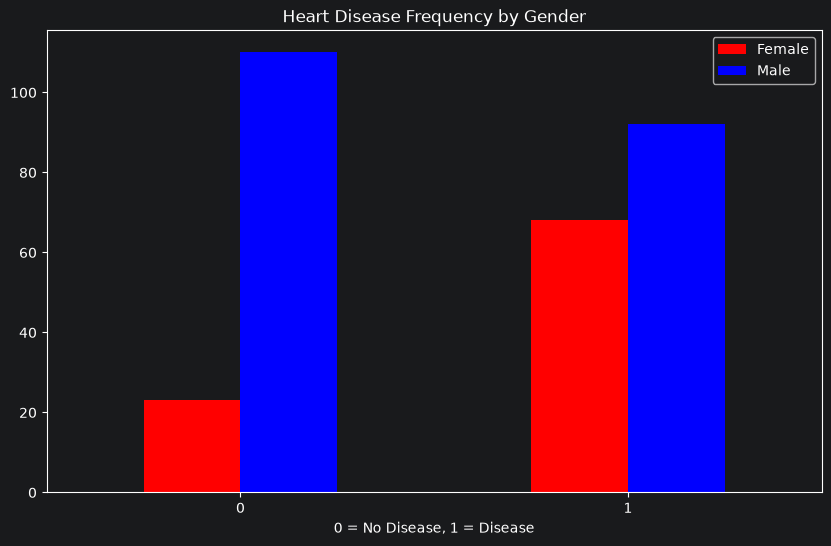

In [17]:
pd.crosstab(df.target, df.sex).plot(kind='bar', figsize=(10,6), color=['red', 'blue'])
plt.title("Heart Disease Frequency by Gender")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.legend(['Female', 'Male'])
plt.xticks(rotation=0)

### Age and Heart rate Correlation

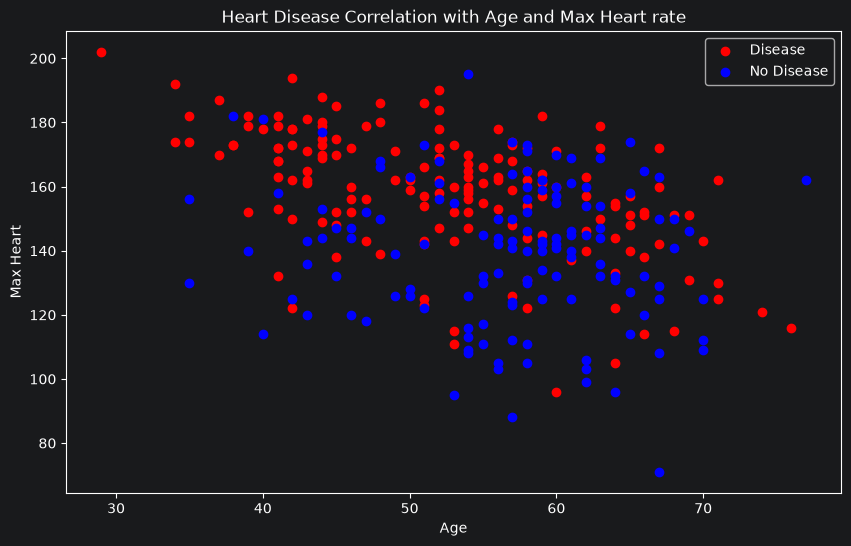

In [20]:
plt.figure(figsize=(10,6))
plt.scatter(df.age[df.target == 1],
            df.thalach[df.target == 1],
            c='red')
plt.scatter(df.age[df.target == 0],
            df.thalach[df.target == 0],
            c='blue')

plt.title("Heart Disease Correlation with Age and Max Heart rate")
plt.xlabel("Age")
plt.ylabel("Max Heart")
plt.legend(['Disease', 'No Disease'])

### Age Distribution

Text(0.5, 0, 'Age')

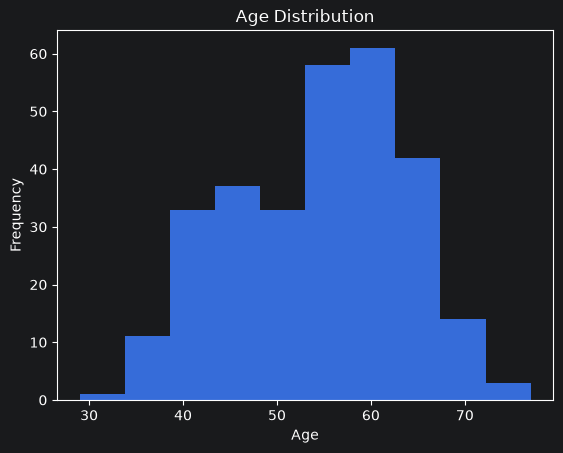

In [23]:
df.age.plot.hist()
plt.title("Age Distribution")
plt.xlabel("Age")

In [25]:
pd.crosstab(index=df.cp, columns=df.target)

target,0,1
cp,,
0,101,37
1,9,41
2,16,66
3,7,16


### Frequency based on Chest Pain Type

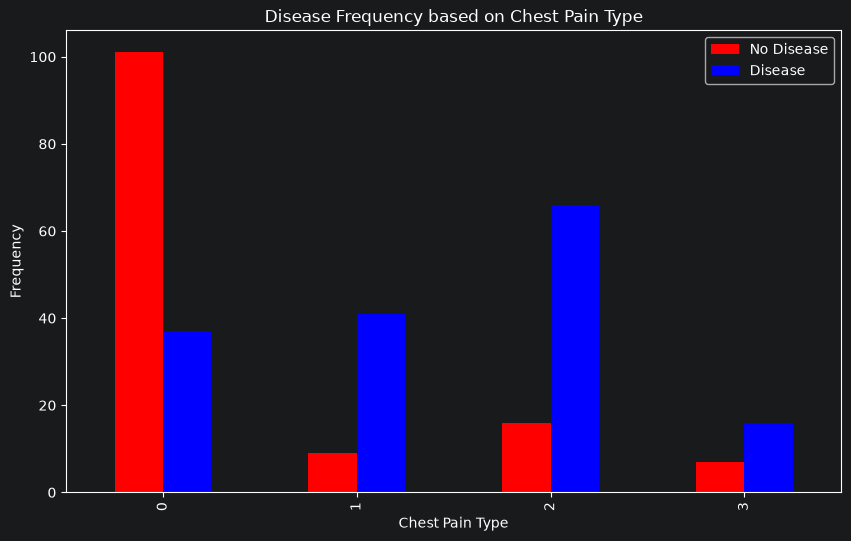

In [31]:
pd.crosstab(df.cp, df.target).plot(kind= 'bar',
                                   color=['red', 'blue'],
                                   figsize=(10,6))
plt.title("Disease Frequency based on Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Frequency")
plt.legend(['No Disease', 'Disease'])

0: Typical angina (chest pain),</br>
1: Atypical angina (chest pain not related to heart), </br>
2: Non-anginal pain (typically esophageal spasms (non heart related), </br>
3: Asymptomatic (chest pain not showing signs of disease)</br>

### Correlation Matrix

In [32]:
corr_matrix = df.corr()

<Axes: >

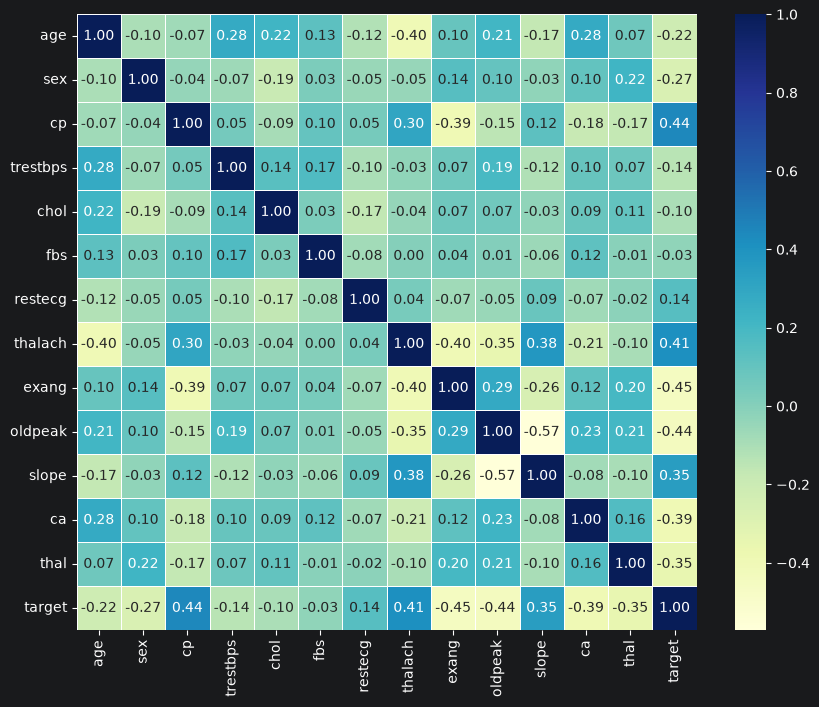

In [45]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot= True,
            fmt=".2f",
            linewidths=0.5,
            cmap="YlGnBu")